In [1]:
import torch
import numpy as np
from transformers import AutoModel
from huggingface_hub import login

T-SNE + umap for raw eeg signal witout any preprocessing exept low and high pass filtering and resample. epochs are 2.5 seconds before onset

In [25]:
from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/reve_eeg_dataset_with_eye.npz"
data = np.load(path, allow_pickle=True)
print(data.files)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['X_eeg', 'y_cls', 'y_reg', 'subject_id', 'session_id', 'ch_names', 'trial_id']


In [26]:
X = data["X_eeg"]                # EEG epochs
y_cls = data["y_cls"]        # left/right class labels
#y_reg = data["y_reg"]        # regression target
subject_id = data["subject_id"]
#session_id = data["session_id"]
#ch_names = data["ch_names"]
#trial_id = data["trial_id"]
print("X shape:", X.shape, X.dtype)
#print("y_cls shape:", y_cls.shape, y_cls.dtype)
#print("y_reg shape:", y_reg.shape, y_reg.dtype)
#print("subject_id shape:", subject_id.shape)
#print("session_id shape:", session_id.shape)
#print("ch_names shape:", ch_names.shape, ch_names.dtype)
#print("trial_id shape:", trial_id.shape)
#print("First channels:", ch_names[:5])

X shape: (5131, 64, 502) float32


In [27]:
fs = 200
last_sec = int(1.0 * fs)

X_last1s = X[:, :,-last_sec:]
last_500ms = int(0.5 * fs)
X_last500ms = X[:,  :,-last_500ms:]
print("X shape:", X_last1s.shape, X_last1s.dtype)
print("X shape:", X_last500ms.shape, X_last500ms.dtype)

X shape: (5131, 64, 200) float32
X shape: (5131, 64, 100) float32


In [28]:
import numpy as np

# X shape: (N, C, T)
mean = X.mean(axis=2, keepdims=True)
std = X.std(axis=2, keepdims=True)

# avoid division by zero
std = np.maximum(std, 1e-6)

X_norm = (X - mean) / std
X_norm = np.clip(X_norm, -15.0, 15.0).astype(np.float32)

print(X_norm.shape, X_norm.dtype)

(5131, 64, 502) float32


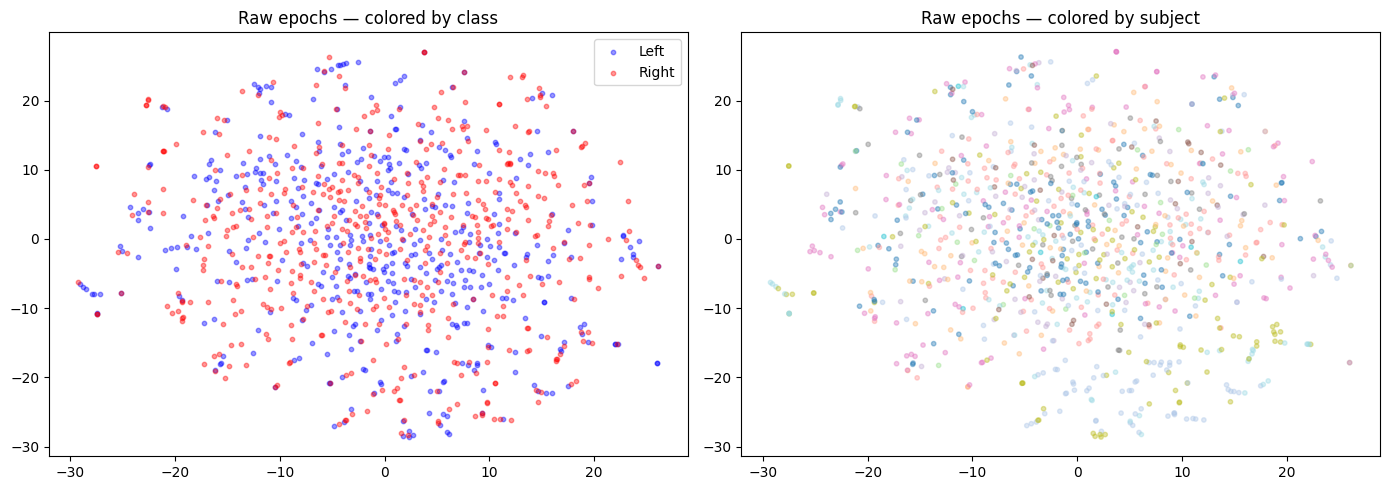

In [29]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
# Flatten raw epochs
X_flat = X_norm.reshape(len(X_norm), -1)  # (N, C*T)
X_flat = PCA(n_components=50).fit_transform(X_flat)
# Subsample if too many trials (t-SNE is slow on large N)
N_SAMPLE = min(1000, len(X_flat))
rng = np.random.default_rng(42)
idx = np.random.choice(len(X_flat), N_SAMPLE, replace=False)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X_flat[idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_2d[y_cls[idx]==0, 0], X_2d[y_cls[idx]==0, 1],
                alpha=0.4, c='blue', s=10, label='Left')
axes[0].scatter(X_2d[y_cls[idx]==1, 0], X_2d[y_cls[idx]==1, 1],
                alpha=0.4, c='red',  s=10, label='Right')
axes[0].legend()
axes[0].set_title("Raw epochs — colored by class")

axes[1].scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.4,
                c=subject_id[idx], cmap='tab20', s=10)
axes[1].set_title("Raw epochs — colored by subject")

plt.tight_layout()
plt.show()

In [30]:
pip install umap-learn

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


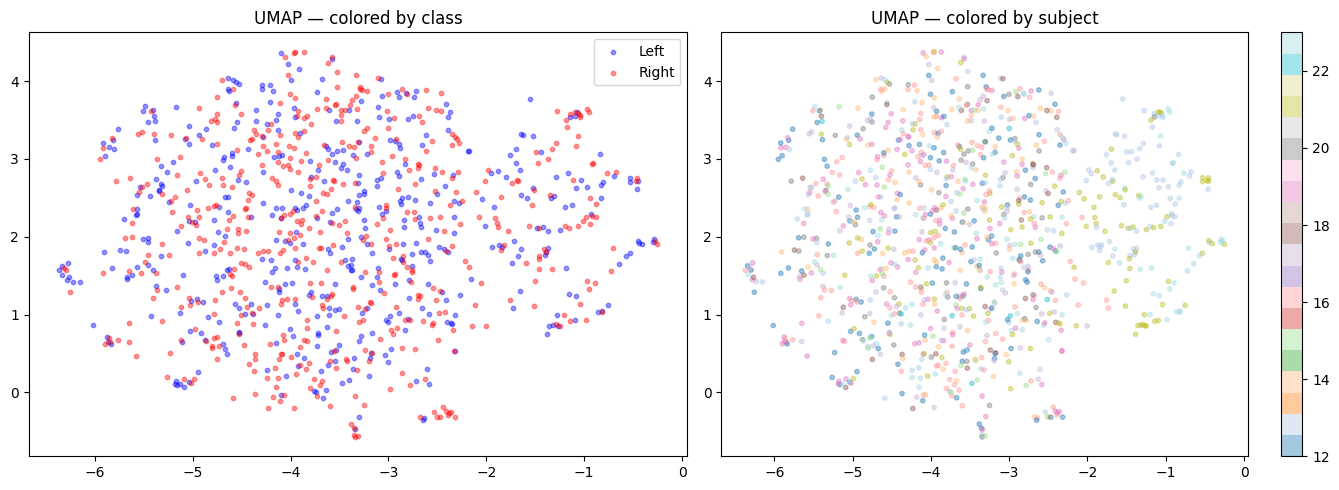

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP


umap = UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
X_2d = umap.fit_transform(X_flat[idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_2d[y_cls[idx]==0, 0], X_2d[y_cls[idx]==0, 1],
                alpha=0.4, c='blue', s=10, label='Left')
axes[0].scatter(X_2d[y_cls[idx]==1, 0], X_2d[y_cls[idx]==1, 1],
                alpha=0.4, c='red', s=10, label='Right')
axes[0].legend()
axes[0].set_title("UMAP — colored by class")

sc = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.4,
                     c=subject_id[idx], cmap='tab20', s=10)
plt.colorbar(sc, ax=axes[1])
axes[1].set_title("UMAP — colored by subject")

plt.tight_layout()
plt.show()

Check shorter window 1sec before and 500ms before

In [32]:
mean = X_last1s.mean(axis=2, keepdims=True)
std = X_last1s.std(axis=2, keepdims=True)

# avoid division by zero
std = np.maximum(std, 1e-6)

X_norm1 = (X_last1s - mean) / std
X_norm1 = np.clip(X_norm1, -15.0, 15.0).astype(np.float32)

print(X_norm1.shape, X_norm1.dtype)

(5131, 64, 200) float32


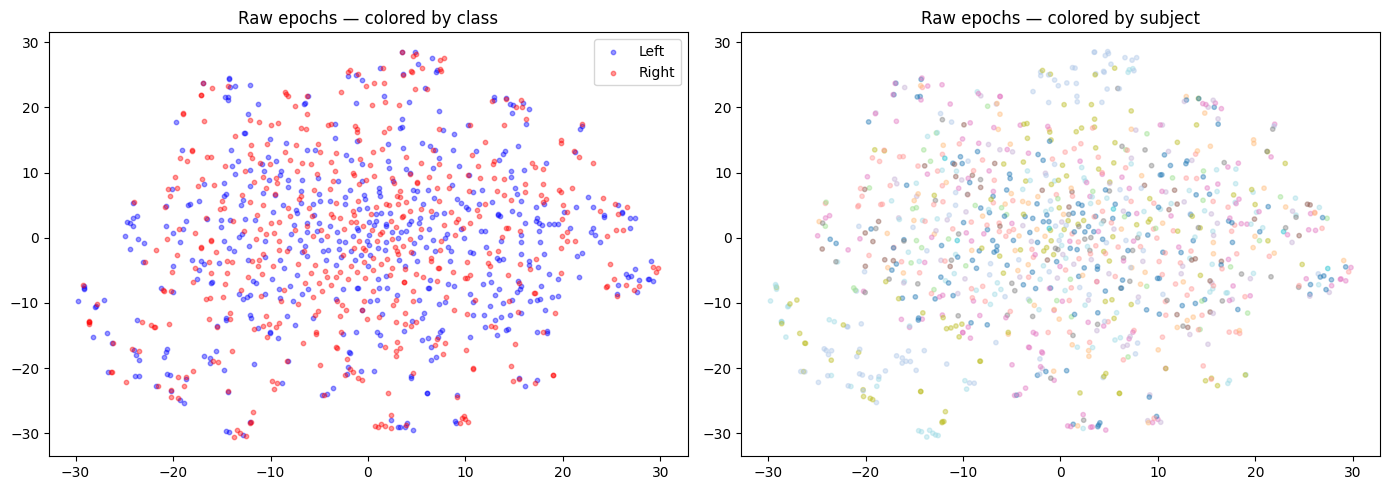

In [33]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
# Flatten raw epochs
X_flat = X_norm1.reshape(len(X_norm1), -1)  # (N, C*T)
X_flat = PCA(n_components=50).fit_transform(X_flat)
# Subsample if too many trials (t-SNE is slow on large N)
N_SAMPLE = min(1000, len(X_flat))
rng = np.random.default_rng(42)
idx = np.random.choice(len(X_flat), N_SAMPLE, replace=False)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X_flat[idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_2d[y_cls[idx]==0, 0], X_2d[y_cls[idx]==0, 1],
                alpha=0.4, c='blue', s=10, label='Left')
axes[0].scatter(X_2d[y_cls[idx]==1, 0], X_2d[y_cls[idx]==1, 1],
                alpha=0.4, c='red',  s=10, label='Right')
axes[0].legend()
axes[0].set_title("Raw epochs — colored by class")

axes[1].scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.4,
                c=subject_id[idx], cmap='tab20', s=10)
axes[1].set_title("Raw epochs — colored by subject")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


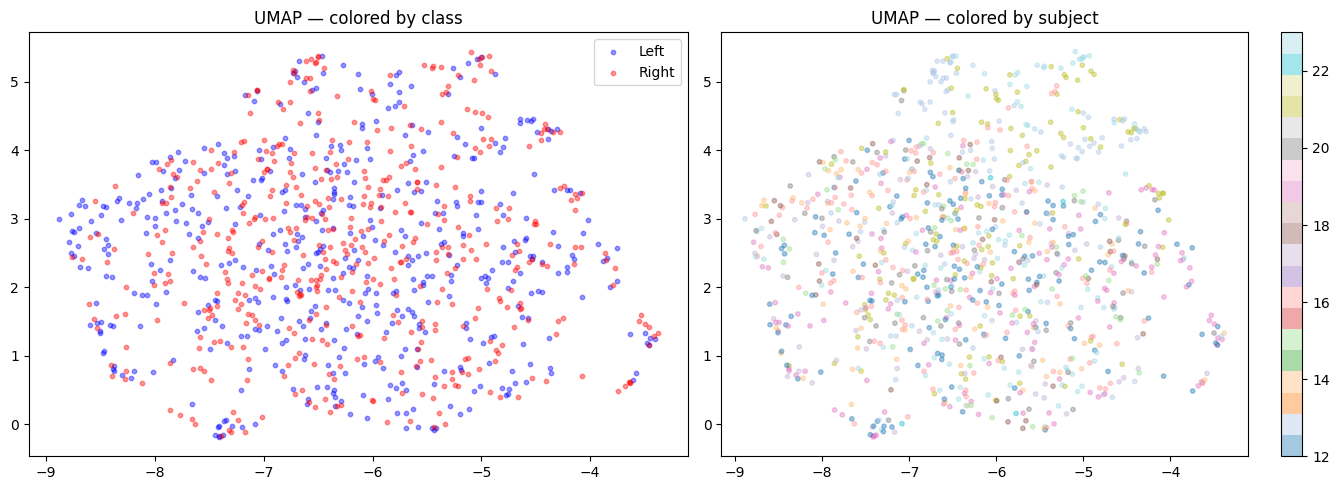

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP


umap = UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
X_2d = umap.fit_transform(X_flat[idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_2d[y_cls[idx]==0, 0], X_2d[y_cls[idx]==0, 1],
                alpha=0.4, c='blue', s=10, label='Left')
axes[0].scatter(X_2d[y_cls[idx]==1, 0], X_2d[y_cls[idx]==1, 1],
                alpha=0.4, c='red', s=10, label='Right')
axes[0].legend()
axes[0].set_title("UMAP — colored by class")

sc = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.4,
                     c=subject_id[idx], cmap='tab20', s=10)
plt.colorbar(sc, ax=axes[1])
axes[1].set_title("UMAP — colored by subject")

plt.tight_layout()
plt.show()

In [35]:
mean = X_last500ms.mean(axis=2, keepdims=True)
std = X_last500ms.std(axis=2, keepdims=True)

# avoid division by zero
std = np.maximum(std, 1e-6)

X_norm2 = (X_last500ms - mean) / std
X_norm2 = np.clip(X_norm2, -15.0, 15.0).astype(np.float32)
print(X_norm2.shape, X_norm2.dtype)

(5131, 64, 100) float32


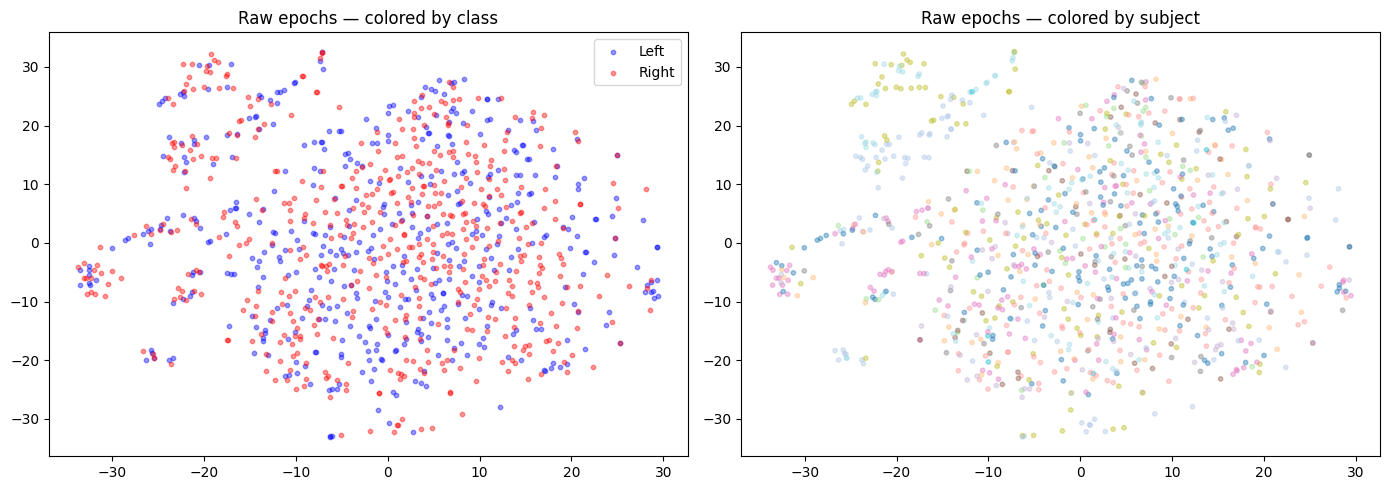

In [36]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
# Flatten raw epochs
X_flat = X_norm2.reshape(len(X_norm2), -1)  # (N, C*T)
X_flat = PCA(n_components=50).fit_transform(X_flat)
# Subsample if too many trials (t-SNE is slow on large N)
N_SAMPLE = min(1000, len(X_flat))
rng = np.random.default_rng(42)
idx = np.random.choice(len(X_flat), N_SAMPLE, replace=False)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X_flat[idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_2d[y_cls[idx]==0, 0], X_2d[y_cls[idx]==0, 1],
                alpha=0.4, c='blue', s=10, label='Left')
axes[0].scatter(X_2d[y_cls[idx]==1, 0], X_2d[y_cls[idx]==1, 1],
                alpha=0.4, c='red',  s=10, label='Right')
axes[0].legend()
axes[0].set_title("Raw epochs — colored by class")

axes[1].scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.4,
                c=subject_id[idx], cmap='tab20', s=10)
axes[1].set_title("Raw epochs — colored by subject")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


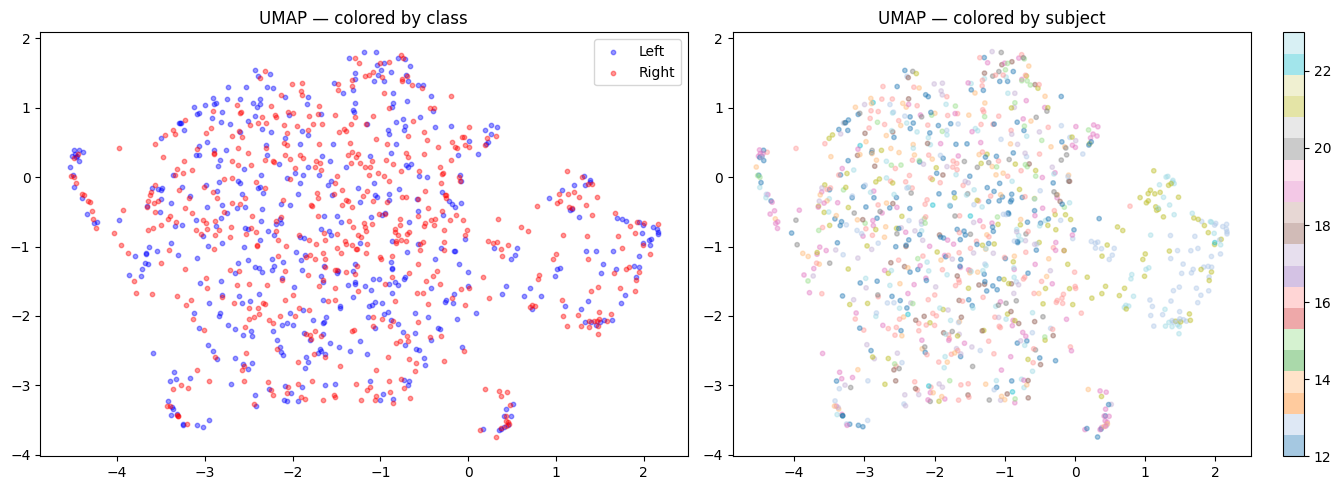

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP


umap = UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
X_2d = umap.fit_transform(X_flat[idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_2d[y_cls[idx]==0, 0], X_2d[y_cls[idx]==0, 1],
                alpha=0.4, c='blue', s=10, label='Left')
axes[0].scatter(X_2d[y_cls[idx]==1, 0], X_2d[y_cls[idx]==1, 1],
                alpha=0.4, c='red', s=10, label='Right')
axes[0].legend()
axes[0].set_title("UMAP — colored by class")

sc = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.4,
                     c=subject_id[idx], cmap='tab20', s=10)
plt.colorbar(sc, ax=axes[1])
axes[1].set_title("UMAP — colored by subject")

plt.tight_layout()
plt.show()

TSNE for preprocessed eeg epochs 1.2 seconds before onset

In [38]:
path1 = "/content/drive/MyDrive/reve_eeg_dataset_epochs_piomegalo.npz"
data1 = np.load(path1, allow_pickle=True)
print(data1.files)

['X', 'y_cls', 'y_reg', 'subject_id', 'session_id', 'ch_names', 'trial_id']


In [39]:
X = data1["X"]                # EEG epochs
y_cls = data1["y_cls"]        # left/right class labels
y_reg = data1["y_reg"]        # regression target
subject_id = data1["subject_id"]
session_id = data1["session_id"]
ch_names = data1["ch_names"]
trial_id = data1["trial_id"]
print("X shape:", X.shape, X.dtype)
print("y_cls shape:", y_cls.shape, y_cls.dtype)
print("y_reg shape:", y_reg.shape, y_reg.dtype)
print("subject_id shape:", subject_id.shape)
print("session_id shape:", session_id.shape)
print("ch_names shape:", ch_names.shape, ch_names.dtype)
print("trial_id shape:", trial_id.shape)
print("First channels:", ch_names[:5])

X shape: (4143, 64, 241) float32
y_cls shape: (4143,) int64
y_reg shape: (4143,) float32
subject_id shape: (4143,)
session_id shape: (4143,)
ch_names shape: (64,) object
trial_id shape: (4143,)
First channels: ['Fp1' 'AF7' 'AF3' 'F1' 'F3']


In [40]:
mean = X.mean(axis=2, keepdims=True)
std = X.std(axis=2, keepdims=True)

# avoid division by zero
std = np.maximum(std, 1e-6)

X_norm = (X - mean) / std
X_norm = np.clip(X, -15.0, 15.0).astype(np.float32)

print(X_norm.shape, X_norm.dtype)

(4143, 64, 241) float32


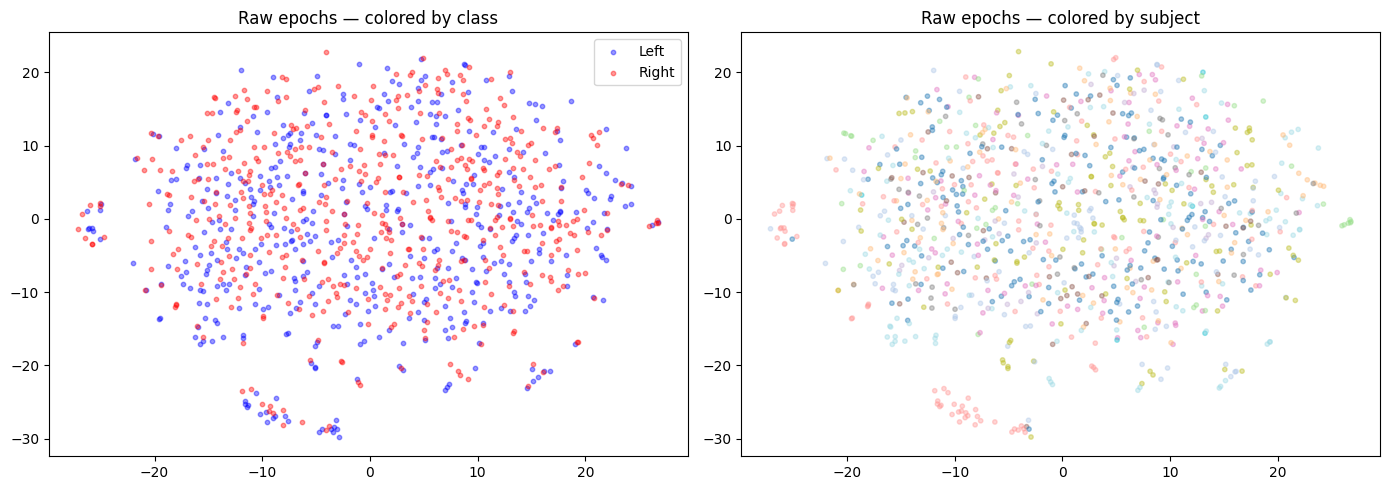

In [41]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
# Flatten raw epochs
X_flat = X_norm.reshape(len(X_norm), -1)  # (N, C*T)
X_flat = PCA(n_components=50).fit_transform(X_flat)
# Subsample if too many trials (t-SNE is slow on large N)
N_SAMPLE = min(1000, len(X_flat))
rng = np.random.default_rng(42)
idx = np.random.choice(len(X_flat), N_SAMPLE, replace=False)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X_flat[idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_2d[y_cls[idx]==0, 0], X_2d[y_cls[idx]==0, 1],
                alpha=0.4, c='blue', s=10, label='Left')
axes[0].scatter(X_2d[y_cls[idx]==1, 0], X_2d[y_cls[idx]==1, 1],
                alpha=0.4, c='red',  s=10, label='Right')
axes[0].legend()
axes[0].set_title("Raw epochs — colored by class")

axes[1].scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.4,
                c=subject_id[idx], cmap='tab20', s=10)
axes[1].set_title("Raw epochs — colored by subject")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


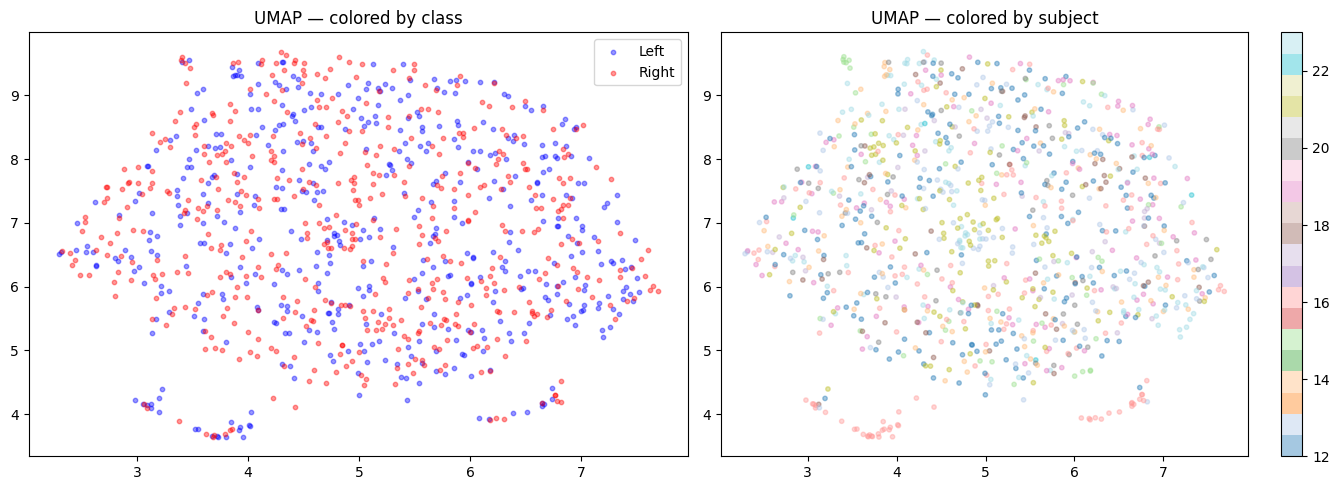

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP


umap = UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
X_2d = umap.fit_transform(X_flat[idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_2d[y_cls[idx]==0, 0], X_2d[y_cls[idx]==0, 1],
                alpha=0.4, c='blue', s=10, label='Left')
axes[0].scatter(X_2d[y_cls[idx]==1, 0], X_2d[y_cls[idx]==1, 1],
                alpha=0.4, c='red', s=10, label='Right')
axes[0].legend()
axes[0].set_title("UMAP — colored by class")

sc = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.4,
                     c=subject_id[idx], cmap='tab20', s=10)
plt.colorbar(sc, ax=axes[1])
axes[1].set_title("UMAP — colored by subject")

plt.tight_layout()
plt.show()